In [16]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier as base_abc
from sklearn.preprocessing import StandardScaler
from adaboost_impl import AdaBoostClassifier as abc
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df= pd.read_csv('../../../datasets/breast_cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
X= df[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean']]
y= df['diagnosis'] 


In [19]:
#splitting data
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state= 127, test_size= 0.2)

In [20]:
print(f'X_train size= ', X_train.shape)
print(f'X_test size= ', X_test.shape)
print(f'y_train size= ', y_train.shape)
print(f'y_test size= ', y_test.shape)

X_train size=  (455, 7)
X_test size=  (114, 7)
y_train size=  (455,)
y_test size=  (114,)


In [21]:
# Preprocessor
num_pipeline= Pipeline(
    steps= [
        ('scaler', StandardScaler())
    ]
)

preprocessor= ColumnTransformer(
    transformers= [
        ('num', num_pipeline, X.columns)
    ]
)

In [22]:
# training model
X_train_= preprocessor.fit_transform(X_train)

clf= abc(learning_rate= 1)
clf.fit(X_train_, y_train)

In [23]:
X_test_= preprocessor.transform(X_test)
y_preds= clf.predict(X_test_)


In [24]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           B       0.96      0.98      0.97        81
           M       0.94      0.91      0.92        33

    accuracy                           0.96       114
   macro avg       0.95      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



Text(50.722222222222214, 0.5, 'Actual')

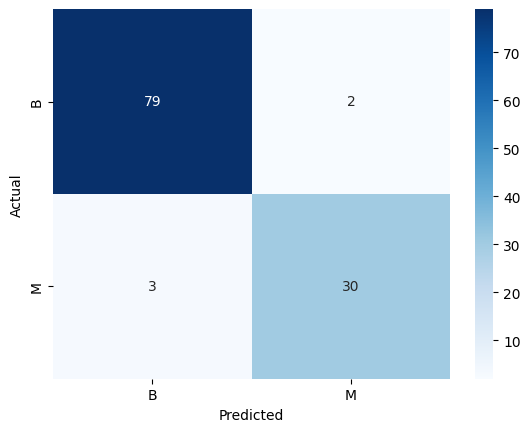

In [25]:
cm= confusion_matrix(y_test, y_preds)

labels= np.unique(np.concatenate([y_test, y_preds]))
sns.heatmap(cm, annot= True, cbar= True, cmap= 'Blues', xticklabels= labels, yticklabels= labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Comparing it to a base model

In [26]:
pipeline= Pipeline(
    steps= [('preprocessor', preprocessor),
            ('model', base_abc(learning_rate= 0.1))
            ]
)

In [27]:
pipeline.fit(X_train, y_train)
y_preds_base= pipeline.predict(X_test)

In [28]:
print(classification_report(y_test, y_preds_base))

              precision    recall  f1-score   support

           B       0.95      0.99      0.97        81
           M       0.97      0.88      0.92        33

    accuracy                           0.96       114
   macro avg       0.96      0.93      0.95       114
weighted avg       0.96      0.96      0.96       114



Text(50.722222222222214, 0.5, 'Actual')

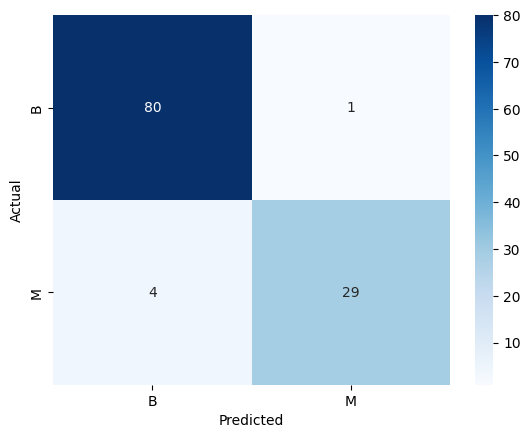

In [29]:
cm= confusion_matrix(y_test, y_preds_base)

labels= np.unique(np.concatenate([y_test, y_preds_base]))
sns.heatmap(cm, annot= True, cbar= True, cmap= 'Blues', xticklabels= labels, yticklabels= labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')